# contains spme explaination of python syntax

## Built-in Function of All python

http://docs.python.org/3/library/functions.html

## Explaination for if __name__ == '__main__':

If the main is invoked, the printf or other output function will not be executed

The beneath codings is instance
the def func() partition will not plot figure, but the if __name__ == '__main__': will if the file is derectly executed. the import print_sine will not plot but if the print_sine() function is invoked the picture will be showed.

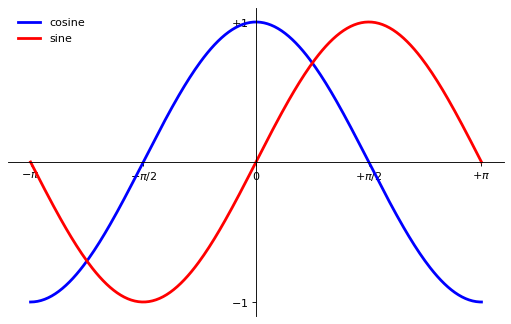

sine function is plottedby hezeqiang


In [1]:
# the file is named as print_sine.py

import os
import numpy as np
import matplotlib.pyplot as plt

def print_sine():
    plt.figure(figsize=(8,5), dpi=80)
    ax = plt.subplot(111)
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.spines['bottom'].set_position(('data',0))
    ax.yaxis.set_ticks_position('left')
    ax.spines['left'].set_position(('data',0))

    X = np.linspace(-np.pi, np.pi, 256,endpoint=True)
    C,S = np.cos(X), np.sin(X)

    plt.plot(X, C, color="blue", linewidth=2.5, linestyle="-", label="cosine")
    plt.plot(X, S, color="red", linewidth=2.5, linestyle="-", label="sine")

    plt.xlim(X.min()*1.1, X.max()*1.1)
    plt.xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi],
               [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$+\pi/2$', r'$+\pi$'])

    plt.ylim(C.min()*1.1,C.max()*1.1)
    plt.yticks([-1, +1],
               [r'$-1$', r'$+1$'])

    plt.legend(loc='upper left', frameon=False)
    # plt.savefig("../figures/exercice_8.png",dpi=72)

    plt.show()
    print('sine function is plotted'+"by hezeqiang")
    
    
if __name__ == '__main__':
    print_sine()

## .item() and enumerate()，.value() for List Tuple Dictionary

In [4]:
d = {'a': 1, 'b': 2, 'c': 3}   
for i, key in enumerate(d):
    print(i,key)

for i, value in enumerate(d.values()):
    print(i,value)

for k, v in d.items():
    print(k, '=', v)


for x, y in [(1, 1), (2, 4), (3, 9)]:
    print(x, y)

0 a
1 b
2 c
0 1
1 2
2 3
a = 1
b = 2
c = 3
1 1
2 4
3 9


## python中*args **kw到底是什么意思？

*args是非关键字参数，用于元组，**kw是关键字参数，用于字典.这两个是python中的可变参数。*args表示任何多个无名参数，它是一个tuple；**kwargs表示关键字参数，它是一个dict。并且同时使用*args和**kwargs时，必须*args参数列要在**kwargs前

In [6]:
def now():
    print('2015-3-25')

f = now # 不会马上执行 
f() # 调用以后执行

#以下方法可以得到 变量函数的函数名

print(f.__name__)


2015-3-25
now


## @log and common @ usage

### python 内置装饰器  ＠staticmethod、＠classmethod 和 @property

装饰器会先执行装饰函数，再利用 return func( * args, ** kw) 返回了原函数，实现了原函数的调用

将类作为参数传递到其他函数中，又希望在实例化这个类之前就能提供某些功能，那么最简单的办法就是使用classmethod和staticmethod。这两者的区别在于在存在类的继承的情况下对多态的支持不同。

( * args, ** kw) 可以实现任意参数的传递

### @property

@property 用于定义两个同名的函数，一个用于读取 getter，一个用于赋值 setter。 没有setter同名函数的就只能读取

### @log


In [2]:
import functools
import time 

def log(text):
    def decorator(func):
        @functools.wraps(func) # 效果等同于 wrapper.__name__ = func.__name__，传递函数
        def wrapper(*args, **kw):        
            print('%s %s()' % (text, func.__name__)) # 每次都会执行
            print("111")
            return func(*args, **kw) # 返回了原函数
        return wrapper
    print("222") # 只会执行一次
    return decorator

"""
# 打印func的执行时间

def log(text):
    def decorator(func):
        @functools.wraps(func) # 效果等同于 wrapper.__name__ = func.__name__，传递函数
        def wrapper(*args, **kw):        
            t1=time.time()
            answer=func(*args, **kw)   # 先执行了原函数
            t2=time.time() 
            t=t2-t1
            print(  text +  func.__name__ +  'time is',  '%s' %( (t*1000)   ),'ms' )# 每次都会执行
            return answer # 返回了原函数
        return wrapper
    return decorator

"""

current_time='2015-3-25'

@log('execute')
def now(*arg):
    print(arg) #每次都会执行，因为最后被返回了

now(current_time)


222
execute now()
111
('2015-3-25',)


### @staticmethod

In [26]:
#!/usr/bin/python
# -*- coding: UTF-8 -*-
 
class C(object):
    @staticmethod
    def f():
        print('runoob');
 
C.f();          # 静态方法无需实例化
cobj = C()
cobj.f()        # 也可以实例化后调用

runoob
runoob


### @ in common usage

假设用 funA() 函数装饰器去装饰 funB() 函数

In [16]:
#funA 作为装饰器函数
def funA(fn):
    #...
    fn() # 执行传入的fn参数
    #...
    return '...'
@funA
def funB():
    #...
    
# 完全等价于以下
def funA(fn):
    #...
    fn() # 执行传入的fn参数
    #...
    return '...'
def funB():
    #...
funB = funA(funB)

IndentationError: expected an indented block (<ipython-input-16-f8a16e7962ff>, line 12)

通过比对以上 2 段程序不难发现，使用函数装饰器 A() 去装饰另一个函数 B()，其底层执行了如下
2 步操作：  
* 将 B 作为参数传给 A() 函数；  
* 将 A() 函数执行完成的返回值反馈回  B。

以下是具体例子

In [17]:
#funA 作为装饰器函数
def funA(fn):
    print("C语言中文网")
    fn() # 执行传入的fn参数
    print("http://c.biancheng.net")
    return "装饰器函数的返回值"
@funA
def funB():
    print("学习 Python")
    
print(funB)

C语言中文网
学习 Python
http://c.biancheng.net
装饰器函数的返回值


显然，被“＠函数”修饰的函数不再是原来的函数，而是被替换成一个新的东西（取决于装饰器的返回值），即如果装饰器函数的返回值为普通变量，那么被修饰的函数名就变成了变量名；同样，如果装饰器返回的是一个函数的名称，怎么被修饰的函数名依然表示一个函数。

## print()

In [3]:
k="hello world "
a=100
print (k+"this is the first day"+" {0}".format(a))

age = 4
name = "hmm"
print("my name is ",name,"age is ",age) #第一种方法。

print("my name is %s, age is %s" %(name,age))#第二种方法。

print("my name is {0} age is {1}".format(name,age))#第三种方法。
# my name is hmm age is 4

hello world this is the first day 100
my name is  hmm age is  4
my name is hmm, age is 4
my name is hmm age is 4


### Python 前导 r'''content'''

Python 中字符串的前导 r 代表原始字符串标识符,也就是说 用r' '表示' '内部的字符串默认不转义

In [27]:
print("\nabc")
print(r"\nabc")


abc
\nabc


label=f'{eta:g}'

python的print字符串前面加f表示格式化字符串，加f后可以在字符串里面使用用花括号括起来的变量和表达式，如果字符串里面没有表达式，那么前面加不加f输出应该都一样.

## printf file
r 是转义符号

r 以只读方式打开文件。文件的指针将会放在文件的开头。这是默认模式。

w 打开一个文件只用于写入。如果该文件已存在则打开文件，并从开头开始编辑，即原有内容会被删除。如果该文件不存在，创建新文件。

w+ 打开一个文件用于读写。如果该文件已存在则打开文件，并从开头开始编辑，即原有内容会被删除。如果该文件不存在，创建新文件。

a 打开一个文件用于追加。如果该文件已存在，文件指针将会放在文件的结尾。也就是说，新的内容将会被写入到已有内容之后。如果该文件不存在，创建新文件进行写入。

In [ ]:
# print to file 1
fname = open('file_name', encoding='utf-8') 
print(r'''title''', file=fname)
print('\ncontent %s' % value, file=fname)
print ("\nPurchase Amount: {0}".format(TotalAmount))
# r 是转义符号
# \n 换行

# print to file 2
text_file = open("Output.txt", "w")
text_file.write("Purchase Amount: %s" % TotalAmount)
text_file.close()

with open("Output.txt", "w") as text_file:
    text_file.write("Purchase Amount: %s" % TotalAmount)
    
    

## error process

raise: 底层的检测手段，判断后返回 错误提醒

try except: 上层的调用手段

当我们认为某些代码可能会出错时，就可以用try来运行这段代码，如果执行出错，则后续代码不会继续执行，而是直接跳转至错误处理代码，即except语句块，执行完except后，如果有finally语句块，则执行finally语句块，至此，执行完毕。  

* 如果当try后的语句执行时发生异常，python就跳回到try并执行第一个匹配该异常的except子句，异常处理完毕，控制流就通过整个try语句（除非在处理异常时又引发新的异常）。
* 如果在try后的语句里发生了异常，却没有匹配的except子句，异常将被递交到上层的try，或者到程序的最上层（这样将结束程序，并打印缺省的出错信息）。
* 如果在try子句执行时没有发生异常，python将执行else语句后的语句（如果有else的话），然后控制流通过整个try语句。


try语句子句形式表  
except: 捕获所有异常  
except name: 只捕获特定的异常  
except name,value: 捕获异常和它的附加数据（将异常的信息保存到value，）  
except (name1,name2): 捕获任何列出的异常  
else: 如果没有异常  
finally: 总是执行  


In [18]:
'''
try:   
    <语句> #运行别的代码  
except <名字>：   
    <语句> #如果在try部份引发了'name'异常  
except <名字>，<数据>:  
    <语句> #如果引发了'name'异常，获得附加的数据  
else:  
    <语句> #如果没有异常发生  
'''

try:
   f = open('file.txt')
except IOError as e:# 只会打印对应于 IOError 的错误，命名为 e
   print (e)
else:
   print ('wrong')

[Errno 2] No such file or directory: 'file.txt'


### try except
The common except contains 
> ZeroDivisionError  
> NameError  
> TypeError  
> ValueError 

the except can solve multiple problems at one senstance

In [24]:
try:
      # codes
except (RuntimeError, TypeError, NameError):
      pass
    
# example  
try:
      x = int(input("Please enter a number: "))
except ValueError:
      print("Oops!  That was no valid number.  Try again...")


IndentationError: expected an indented block (<ipython-input-24-95fbb129df1c>, line 9)

In [ ]:
import sys

try:
      f = open('myfile.txt')
      s = f.readlines()     # 读一行
      i = int(s.strip())    # 去除字符串开头和结尾处指定的字符
except OSError as err:
      print("OS error: {0}".format(err))
except ValueError:
      print("Could not convert data to an integer.")
except:
      print("Unexpected error:", sys.exc_info()[0])
      raise                 # 再打印一次error
else:
      print("succeed without excepts!!!")
      f.close()

### raise func()

raise是一种可以强制指定错误类型并输出错误提示的函数，是为try and except 服务的，一般模块里都自带的。
也可以自己编写raise，实现特定功能。

raise 一共有三种用法：
* raise：单独一个 raise。该语句引发当前上下文中捕获的异常（比如在 except 块中），或默认引发 RuntimeError 异常。
> raise     
>RuntimeError: No active exception to reraise
* raise 异常类名称：raise 后带一个异常类名称，表示引发执行类型的异常。
> raise ZeroDivisionError      
>ZeroDivisionError
* raise 异常类名称(描述信息)：在引发指定类型的异常的同时，附带异常的描述信息。
> raise ZeroDivisionError("除数不能为零")    
>ZeroDivisionError: 除数不能为零

其中 raise KeyboardInterrupt 属于第二种，但不会抛出错误
以下是大多数error

      class Exception(BaseException): ...  # Exception是自定义except的函数接口，可以自定义出错的print
      
      class BlockingIOError(OSError):...
      class ChildProcessError(OSError): ...
      class ConnectionError(OSError): ...
      class BrokenPipeError(ConnectionError): ...
      class ConnectionAbortedError(ConnectionError): ...
      class ConnectionRefusedError(ConnectionError): ...
      class ConnectionResetError(ConnectionError): ...
      class FileExistsError(OSError): ...
      class FileNotFoundError(OSError): ...
      class InterruptedError(OSError): ...
      class IsADirectoryError(OSError): ...
      class NotADirectoryError(OSError): ...
      class PermissionError(OSError): ...
      class ProcessLookupError(OSError): ...
      class TimeoutError(OSError): ...
      class Exception(BaseException): ...
      class ImportError(_StandardError)...
      class TypeError(_StandardError): ...
      class ValueError(_StandardError): ...
      class FloatingPointError(ArithmeticError): ...
      class OverflowError(ArithmeticError): ...
      class ZeroDivisionError(ArithmeticError): ...
      class IndexError(LookupError): ...
      class KeyError(LookupError): ...

In [25]:
####################################################################################
###  自定义1
try:
      a = input("输入一个数：")
    #判断用户输入的是否为数字
      if(not a.isdigit()): 
            raise ValueError("a 必须是数字")
      print("sucess!")                # 触发异常后，后面的代码就不会再执行              
except ValueError as e:               # 对应了前面的
      print("引发异常：",repr(e))


####################################################################################
###  自定义2
try:
      a = input("输入一个数：")
    #判断用户输入的是否为数字
      if(not a.isdigit()): 
            raise ValueError("a 必须是数字")
      print("sucess!")                # 触发异常后，后面的代码就不会再执行              
except ValueError as e:               # 对应了前面的
      print("引发异常：",repr(e))
      raise                           # 这里会再一次引发 ValueError("a 必须是数字")，一般不会写
      
####################################################################################
###  自定义3  利用 exception
def mye( level ):
      a = input("输入一个数：")
      if level < a:
            raise Exception("small!")    # Exception是自定义except的函数接口
        # 触发异常后，后面的代码就不会再执行
      else:
            print("a is big enough")
try:
    mye(0)            # 触发异常
except Exception as err:
    print(1,err)
else:
    print(2)

####################################################################################
##   自定义4   默认情况下是 RuntimeError
try:
    a = input("输入一个数：")
    if(not a.isdigit()):
        raise
except RuntimeError as e:
    print("引发异常：",repr(e))


输入一个数： 2


sucess!


输入一个数： 3


sucess!


输入一个数： 4


1 '<' not supported between instances of 'int' and 'str'


输入一个数： 5


## Generator usage

the invoking of generator is by function next() ,just like yield() in loop and if

In [21]:
#可见用filter()这个高阶函数，关键在于正确实现一个“筛选”函数。
#注意返回的是一个 iterator ，用list() 返回函数
def _odd_iter():
    n = 1
    while True:
        n = n + 2
        yield n
#注意这是一个生成器，并且是一个无限序列。
#一般来说 n 是在定义函数的一次循环里面
#然后定义一个筛选函数：
def _not_divisible(n):
    return lambda x: x % n > 0

#最后，定义一个生成器，不断返回下一个素数：
def primes():
    yield 2
    it=_odd_iter()# 初始序列
    while True:
        n=next(it)
        yield n
        it = filter(_not_divisible(n), it)

t=primes()

print(next(t))

print(next(t))
#for i in primes():
#    print(i)class Student(object):

def __init__(self, name, score):  #属性绑定专用函数
    self.__name = name            #属性在实例后面加上 .
    self.__score = score


2
3


## Class

类中的函数叫方法  
类中的变量叫属性  
实例是类的对象

In [23]:
class Student(object):

    def __init__(self, name="stuudent", score=0):  #属性绑定专用函数
        self.__name = name            #属性在实例后面加上 
        self.__score = score

    def get_name(self):
        return self.__name

    def get_score(self):
        return self.__score
    
    def set_newname(self,newname):   # set the newname by method rather than diret invoking
        self.__name = newname
    
            
    def set_score(self, value):
        if not isinstance(value, int):
            raise ValueError('score must be an integer!')
        if value < 0 or value > 100:
            raise ValueError('score must between 0 ~ 100!')
        self.__score = value
    


# initial value can be set even as the private property
hezeqiang = Student("hezeqiang",100)
wangqun = Student()
hezeqiang.set_newname("hezeqiang2")

print(hezeqiang.get_name())
print(wangqun.get_name())

# 继承
class Sinior_stu(Student):
    pass

class Junior_stu(Student):
    pass


# 配合getattr()、setattr()以及hasattr()，我们可以直接操作一个对象的状态：
# get attribute , set attribute , has attribute?
Sinior_hezeqiang = Sinior_stu(hezeqiang, 100)

print(hasattr(Sinior_hezeqiang, 'get_name'))
print(getattr(Sinior_hezeqiang, 'z', 404) )# 获取属性'z'，如果不存在，返回默认值404

Sinior_hezeqiang

hezeqiang2
stuudent
True
404


## Underline effect

1、_单下划线开头：“from M import *”将不导入所有以下划线开头的对象，包括包，模块、成员。但是可以通过module._variableName访问. 如果是类内变量或者函数，则表示为保护对象，只可被类与子类对象使用       _index

“from M import *”将不导入所有以下划线开头的对象,且我虽然可以访问，但我希望不要被访问


2、单下划线结尾 __ 只是为了避免与python关键字的命名冲突。      count__

3、__ 双下划线开头：模块内的成员，表示私有成员，外部无法直接调用。        __count

4、__ 双下划线开头双下划线结尾__：指那些python类中的特殊函数或属性，如__name__，__doc__，__init__，__import__，__file__，__setattr__，__getattr__，__dict__等，自己写变量和函数、方法名不推荐这样的方式。          __contains__


## numpy

In [3]:
import numpy as np
from math import *

x=np.arange(1,200,2)
print(list(map(sin, x)))

[0.8414709848078965, 0.1411200080598672, -0.9589242746631385, 0.6569865987187891, 0.4121184852417566, -0.9999902065507035, 0.4201670368266409, 0.6502878401571168, -0.9613974918795568, 0.14987720966295234, 0.8366556385360561, -0.8462204041751706, -0.13235175009777303, 0.956375928404503, -0.6636338842129675, -0.404037645323065, 0.9999118601072672, -0.428182669496151, -0.6435381333569995, 0.9637953862840878, -0.158622668804709, -0.8317747426285983, 0.8509035245341184, 0.123573122745224, -0.9537526527594719, 0.6702291758433747, 0.39592515018183416, -0.9997551733586199, 0.43616475524782494, 0.6367380071391379, -0.9661177700083929, 0.16735570030280691, 0.8268286794901034, -0.8555199789753223, -0.11478481378318722, 0.9510546532543747, -0.6767719568873076, -0.38778163540943045, 0.9995201585807313, -0.4441126687075084, -0.6298879942744539, 0.9683644611001854, -0.1760756199485871, -0.8218178366308225, 0.8600694058124532, 0.10598751175115685, -0.9482821412699473, 0.683261714736121, 0.379607739027

In [7]:
import os
os.name

'nt'

In [8]:
import json
d = dict(name='Bob', age=20, score=88)
json.dumps(d)

'{"name": "Bob", "age": 20, "score": 88}'

In [9]:
from multiprocessing import Process
import os

# 子进程要执行的代码
def run_proc(name):
    print('Run child process %s (%s)...' % (name, os.getpid()))

if __name__=='__main__':
    print('Parent process %s.' % os.getpid())
    p = Process(target=run_proc, args=('test',))
    print('Child process will start.')
    p.start()
    p.join()
    print('Child process end.')

Parent process 20192.
Child process will start.
Child process end.


In [1]:
from multiprocessing import Pool
import os, time, random

def long_time_task(name):
    print('Run task %s (%s)...' % (name, os.getpid()))
    start = time.time()
    time.sleep(random.random() * 3)
    end = time.time()
    print('Task %s runs %0.2f seconds.' % (name, (end - start)))

if __name__=='__main__':
    print('Parent process %s.' % os.getpid())
    p = Pool(4)
    for i in range(5):
        p.apply_async(long_time_task(i), args=(i,))
    print('Waiting for all subprocesses done...')
    p.close()
    p.join()
    print('All subprocesses done.')

Parent process 34364.
Run task 0 (34364)...
Task 0 runs 2.69 seconds.
Run task 1 (34364)...
Task 1 runs 2.98 seconds.
Run task 2 (34364)...
Task 2 runs 1.73 seconds.
Run task 3 (34364)...
Task 3 runs 2.35 seconds.
Run task 4 (34364)...
Task 4 runs 1.86 seconds.
Waiting for all subprocesses done...
All subprocesses done.


In [4]:
from multiprocessing import Process, Queue
import os, time, random

# 写数据进程执行的代码:
def write(q):
    print('Process to write: %s' % os.getpid())
    for value in ['A', 'B', 'C']:
        print('Put %s to queue...' % value)
        q.put(value)
        time.sleep(random.random())

# 读数据进程执行的代码:
def read(q):
    print('Process to read: %s' % os.getpid())
    while True:
        value = q.get(True)
        print('Get %s from queue.' % value)

if __name__=='__main__':
    # 父进程创建Queue，并传给各个子进程：
    q = Queue()
    pw = Process(target=write, args=(q,))
    pr = Process(target=read, args=(q,))
    # 启动子进程pw，写入:
    pw.start()
    # 启动子进程pr，读取:
    pr.start()
    # 等待pw结束:
    pw.join()
    # pr进程里是死循环，无法等待其结束，只能强行终止:
    pr.terminate()

In [5]:
r'ABC\-001'

'ABC\\-001'

In [6]:
'ABC\\-001'

'ABC\\-001'

In [8]:
from datetime import datetime, timedelta
now = datetime.now()
print(now.strftime('%Y-%m-%d %H:%M:%S'))

now + timedelta(days=2, hours=12)

2023-08-01 20:43:17


datetime.datetime(2023, 8, 4, 8, 43, 17, 507843)

In [10]:
from collections import namedtuple
Point = namedtuple('Point', ['x', 'y'])
p = Point(1, 2)
p.x

1

In [11]:
from collections import deque
q = deque(['a', 'b', 'c'])
q.append('x')
q.appendleft('y')
q

deque(['y', 'a', 'b', 'c', 'x'])

In [15]:
from collections import ChainMap

# Create dictionaries to be chained
dict1 = {'a': 1, 'b': 2}
dict2 = {'b': 3, 'c': 4}
dict3 = {'c': 5, 'd': 6}

# Create a ChainMap with the dictionaries
chain_map = ChainMap(dict1, dict2, dict3)

# Access values
print(chain_map['a'])  # Output: 1
print(chain_map['b'])  # Output: 2 (from dict1)
print(chain_map['c'])  # Output: 4 (from dict2)
print(chain_map['d'])  # Output: 6 (from dict3)

# Update values
chain_map['b'] = 7
print(chain_map['b'])  # Output: 7 (value in dict1 is updated)
print(dict1, dict2, dict3)

1
2
4
6
7
{'a': 1, 'b': 7} {'b': 3, 'c': 4} {'c': 5, 'd': 6}


In [21]:
from collections import Counter

# Create a list with elements
data = [1, 2, 3, 2, 1, 3, 4, 5, 4, 4, 5]

# Create a Counter object from the list
counter = Counter(data)

print(counter)
# Output: Counter({4: 3, 1: 2, 3: 2, 2: 2, 5: 2})

# Access individual counts
print(counter[4])  # Output: 3 (count of 4)
print(counter[1])  # Output: 2 (count of 1)

c = Counter('programming')
print(c)

Counter({4: 3, 1: 2, 2: 2, 3: 2, 5: 2})
3
2
Counter({'r': 2, 'g': 2, 'm': 2, 'p': 1, 'o': 1, 'a': 1, 'i': 1, 'n': 1})


In [26]:
multiples = [2 * i+1 for i in range(30) if i % 3 == 0]
multiples

[1, 7, 13, 19, 25, 31, 37, 43, 49, 55]